In [41]:
pip install pandas-datareader #Pandas datareader allows you to read stock information directly from the internet 

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#Pandas'


In [7]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [3]:
from pandas_datareader import data as wb
import pandas as pd
import numpy as np
import datetime
%matplotlib inline
import yfinance as yf

In [19]:
#We need to get data using pandas datareader. We will get stock information for the following banks:

#Bank of America
#CitiGroup
#Goldman Sachs
#JPMorgan Chase
#Morgan Stanley
#Wells Fargo
#** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**

#Use datetime to set start and end datetime objects.
#Figure out the ticker symbol for each bank.
#Figure out how to use datareader to grab info on the stock.
#** Use this documentation page for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**

 # Download Bank of America (BAC) data
BAC = yf.download("BAC", start=start, end=end)


[*********************100%***********************]  1 of 1 completed


In [17]:
start = datetime.datetime(2006, 1, 1)
end = datetime.datetime(2026, 1, 1)

In [20]:
 

# Download all tickers at once
bank_data = yf.download(['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC'], start=start, end=end)

# Access individual banks from the MultiIndex if needed
BAC = bank_data.xs('BAC', level=1, axis=1)


[*********************100%***********************]  6 of 6 completed


In [22]:
#Bank of America
#BAC = wb.DataReader("BAC", 'yahoo', start, end)

# CitiGroup
C = bank_data.xs('C', level=1, axis=1)


# Goldman Sachs
GS = bank_data.xs('GS', level=1, axis=1)


# JPMorgan Chase
JPM = bank_data.xs('JPM', level=1, axis=1)

# Morgan Stanley
MS = bank_data.xs('MS', level=1, axis=1)


# Wells Fargo
WFC =  bank_data.xs('WFC', level=1, axis=1)

In [23]:
#df = data.DataReader(['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC'],'google', start, end)

In [24]:
#Creating a lsit of the tickers(as Strings).
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

In [29]:
#cancatenating bank data frame.
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC],axis=1,keys=tickers)

In [31]:
bank_stocks.head()

BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Date                                                                           
2006-01-03  30.487934  30.552691  29.885687  30.384319  16296700  315.803619   
2006-01-04  30.164143  30.591543  30.079957  30.436124  17757900  309.973267   
2006-01-05  30.202999  30.326040  29.995775  30.164146  14970700  311.510834   
2006-01-06  30.157671  30.377847  30.015203  30.306613  12599800  311.510834   
2006-01-09  30.177103  30.416708  30.021686  30.254814  15619400  310.037231   

                                                         ...         MS  \
Price             High         Low        Open   Volume  ...      Close   
Date                                                     ...              
2006-01-03  316.380250  308.243305  313.945578  1537600  ...  31.349607   
2006-01-04  314.586353  309.781063  313.048664  1870960  ...  31.371115   
2006-01-05  312.535946  310.101275  310.357553  1143160  ...  31.457142   
2006-01-06  313.304800  308.819864  313.176651  1370210  ...  31.489407   
2006-01-09  312.279700  309.460601  311.382716  1680740  ...  31.822741   

                                                            WFC             \
Price            High        Low       Open   Volume      Close       High   
Date                                                                         
2006-01-03  31.446382  30.505518  30.736700  5377000  18.379141  18.422352   
2006-01-04  31.871117  31.371115  31.559289  7977800  18.165970  18.333052   
2006-01-05  31.500154  31.193701  31.478648  5778000  18.145809  18.180378   
2006-01-06  31.639944  31.209835  31.596934  6889800  18.252386  18.307120   
2006-01-09  31.876505  31.516288  31.521665  4144500  18.249510  18.335933   

                                            
Price             Low       Open    Volume  
Date                                        
2006-01-03  17.972956  18.206297  11016400  
2006-01-04  18.070905  18.321529  10870000  
2006-01-05  18.039221  18.148689  10158000  
2006-01-06  18.082422  18.194771   8403800  
2006-01-09  18.180373  18.249510   5619600  

[5 rows x 30 columns]

In [49]:
bank_stocks.columns.names=['Bank Ticker','Stock info']

In [43]:
MS

Price,Close,High,Low,Open,Volume
Date,,,,,
2006-01-03,31.349607,31.446382,30.505518,30.736700,5377000
2006-01-04,31.371115,31.871117,31.371115,31.559289,7977800
2006-01-05,31.457142,31.500154,31.193701,31.478648,5778000
2006-01-06,31.489407,31.639944,31.209835,31.596934,6889800
2006-01-09,31.822741,31.876505,31.516288,31.521665,4144500
...,...,...,...,...,...
2025-12-24,180.654114,181.002201,178.545741,179.172292,2648000
2025-12-26,180.872910,181.340334,180.107142,180.853030,2564700
2025-12-29,178.953491,180.703837,178.764530,180.196638,2464300


In [55]:
#EDA
# What is the max Close price for each banks stock throughout the time period?
bank_stocks.xs(key='Close',axis=1,level=1).max()

Bank Ticker
BAC     55.933796
C      376.505157
GS     906.260620
JPM    326.023376
MS     180.872910
WFC     94.833908
dtype: float64

In [57]:
#Create a new empty dataFrame called returns.This dataframe will contains the returns for each bank's stock.returns are typically defined by:
returns = pd.DataFrame()

In [61]:
#use pct_change() method on the Close column to create a column representing this return value. create a for loop that goes and for each bank
#stock Ticker creates this returns column and set's it as a column in the retruns dataframe
for tick in tickers:
    returns[tick+' Return'] = bank_stocks[tick]['Close'].pct_change()
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.005771,0.000686,-0.011599
2006-01-05,0.001288,0.004960,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005873
2006-01-09,0.000644,-0.004731,0.012031,0.016242,0.010586,-0.000158


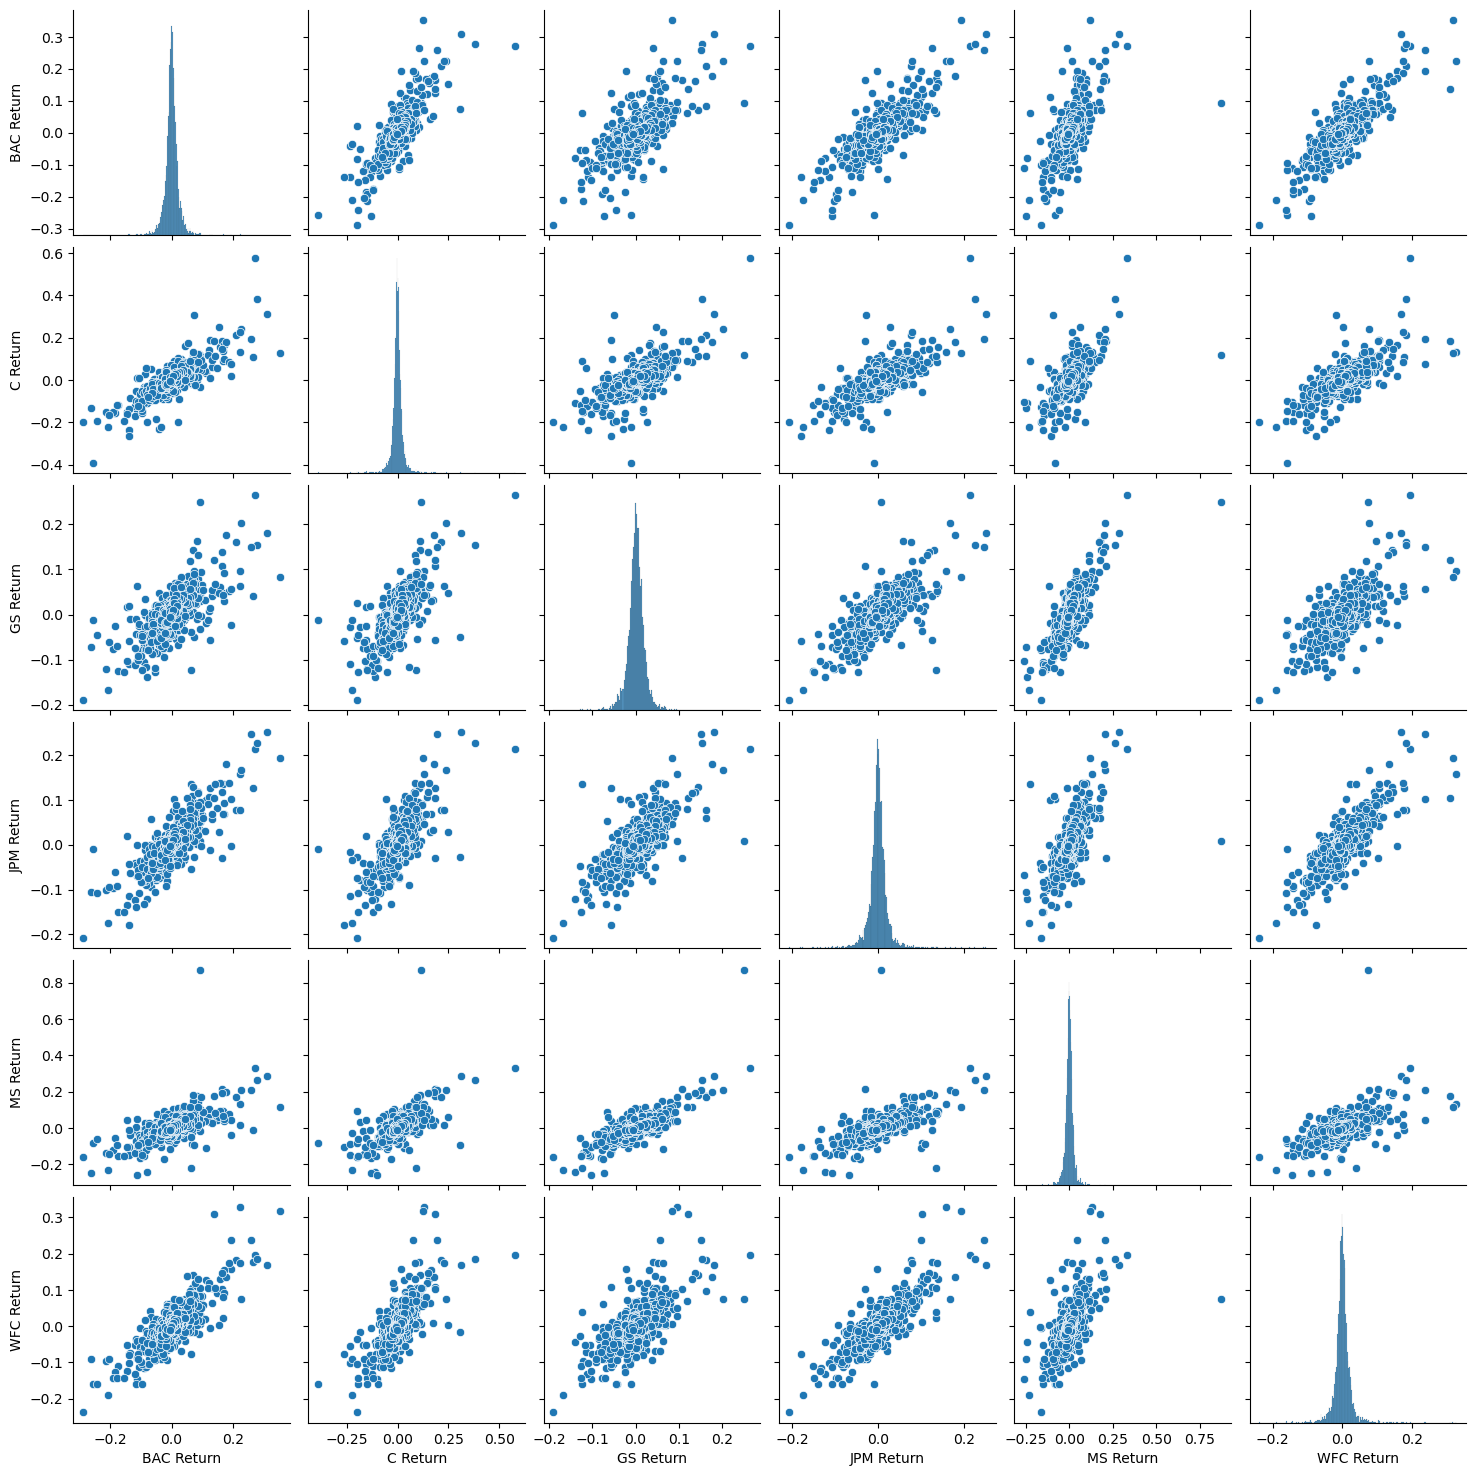

In [63]:
#Create a pairplot using seaborn of the returns dataframe.What stocks standsout to you?
#Can you figure out why?
#returns[1:]
import seaborn as sns
sns.pairplot(returns[1:])

In [65]:
#** Using this returns DataFrame, figure out on what dates each bank stock had the best 
#and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, 
#did anything significant happen that day?**

In [73]:
# Worst Drop (4 of them on Inauguration day)
#returns.min()
#returns['BAC Return'].argmin()---this is for single columns
returns.idxmin()  # for all data set


#** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

In [79]:
# Best Single Day Gain
# citigroup stock split in May 2011, but also JPM day after inauguration. 
returns.idxmax() 

BAC Return   2009-04-09
C Return     2008-11-24
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

In [81]:
 #** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**
 returns.std() # Citigroup riskiest


 

BAC Return    0.029415
C Return      0.031131
GS Return     0.022284
JPM Return    0.023108
MS Return     0.030194
WFC Return    0.025699
dtype: float64

In [97]:
returns.loc['2025-01-01':'2025-12-31'].std() # Very similar risk profiles, but Morgan Stanley or BofA

BAC Return    0.016831
C Return      0.019801
GS Return     0.019648
JPM Return    0.015654
MS Return     0.019283
WFC Return    0.018322
dtype: float64

C:\Users\cprad\AppData\Local\Temp\ipykernel_18872\1060900020.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2025-01-01':'2025-12-31']['MS Return'],color='green',bins=100)


<Axes: xlabel='MS Return', ylabel='Density'>

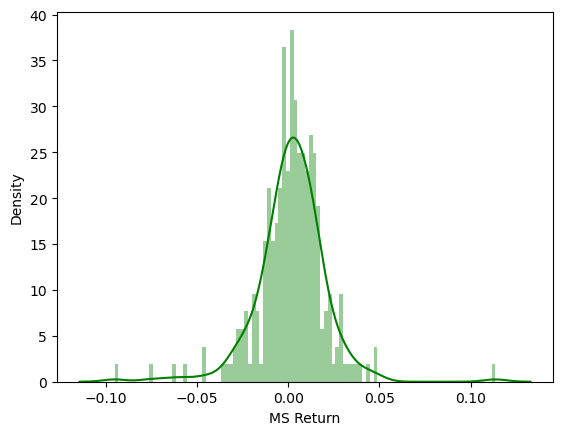

In [109]:
#** Create a distplot using seaborn of the 2015 returns for Morgan Stanley *
sns.distplot(returns.loc['2025-01-01':'2025-12-31']['MS Return'],color='green',bins=100)

 

C:\Users\cprad\AppData\Local\Temp\ipykernel_18872\2292972029.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(returns.loc['2008-01-01':'2008-12-31']['MS Return'],color='green',bins=100)


<Axes: xlabel='MS Return', ylabel='Density'>

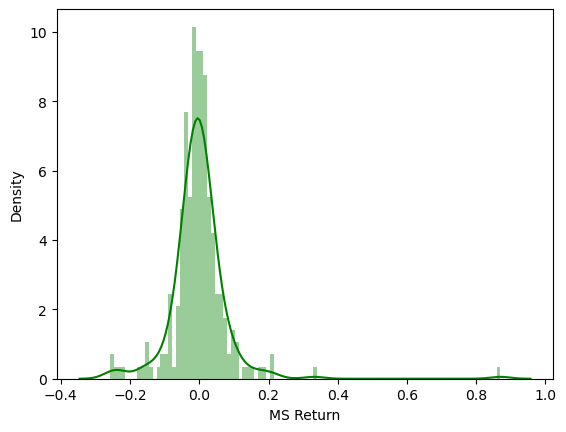

In [111]:
#Create a displot using seaborn of the 2008 retuuns for CitiGroup
sns.distplot(returns.loc['2008-01-01':'2008-12-31']['MS Return'],color='green',bins=100)

In [ ]:
#More Visualization
#A lot of this project will focus on visualizations. Feel free to use any of your preferred
#visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

In [115]:
#** Create a line plot showing Close price for each bank for the entire index of time.
#(Hint: Try using a for loop, or use .xs to get a cross section of the data.)**

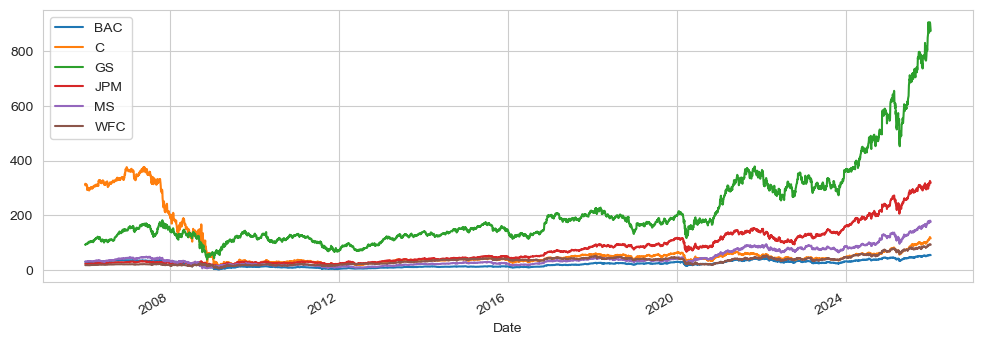

In [117]:
for tick in tickers:
    bank_stocks[tick]['Close'].plot(figsize=(12,4),label=tick)
plt.legend()

<Axes: xlabel='Date'>

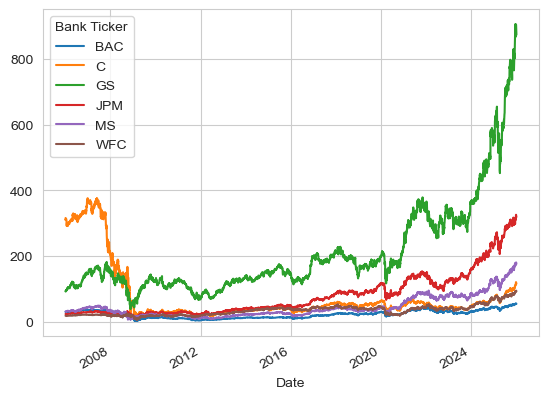

In [125]:
bank_stocks.xs(key='Close',axis=1,level=1).plot()

C:\Users\cprad\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



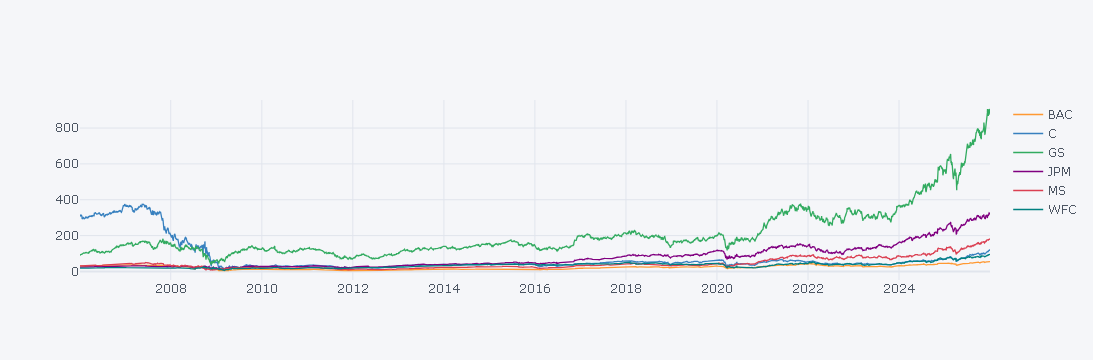

In [127]:
bank_stocks.xs(key='Close',axis=1,level=1).iplot()

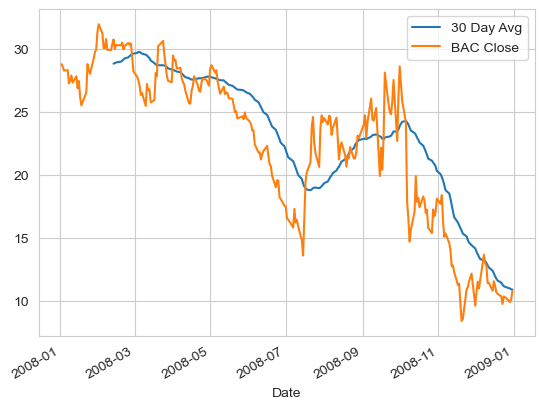

In [135]:
#Moving Averages
#Let's analyze the moving averages for these stocks in the year 2008.

#** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**
BAC['Close'].loc['2008-01-01':'2009-01-01'].rolling(window=30).mean().plot(label='30 Day Avg')
BAC['Close'].loc['2008-01-01':'2009-01-01'].plot(label='BAC Close')
plt.legend()

In [137]:
#Lets create a heat map of the correlation btw the ctocks closing Price.

<Axes: xlabel='Bank Ticker', ylabel='Bank Ticker'>

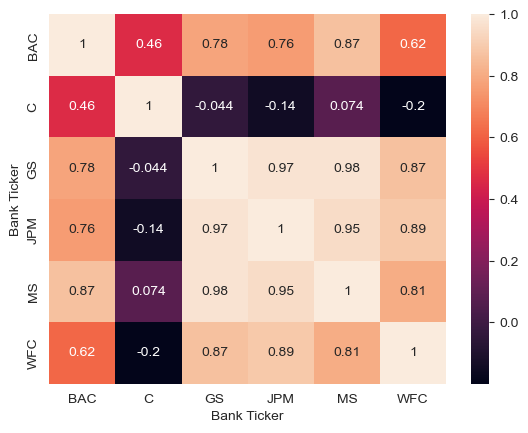

In [143]:
sns.heatmap(bank_stocks.xs(key='Close',axis=1,level=1).corr(),annot= True)

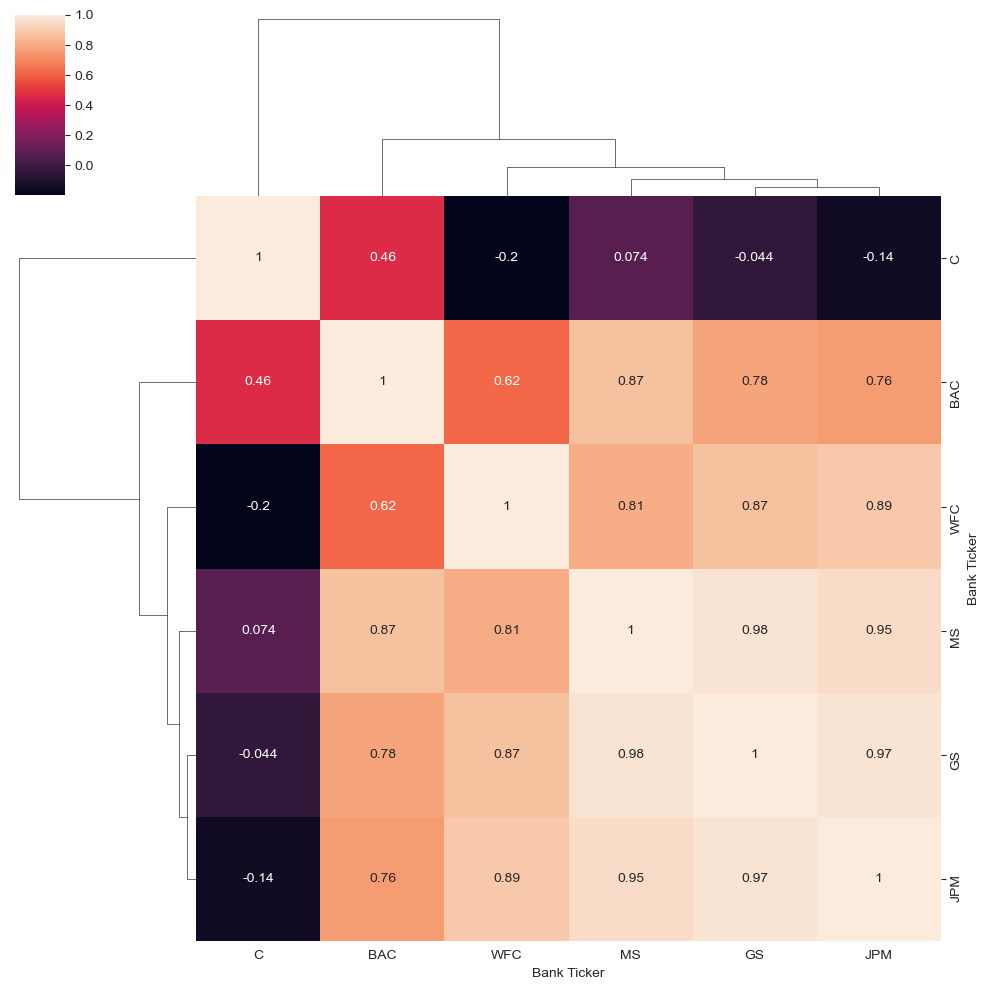

In [145]:
# Clustered map
sns.clustermap(bank_stocks.xs(key='Close',axis=1,level=1).corr(),annot= True)

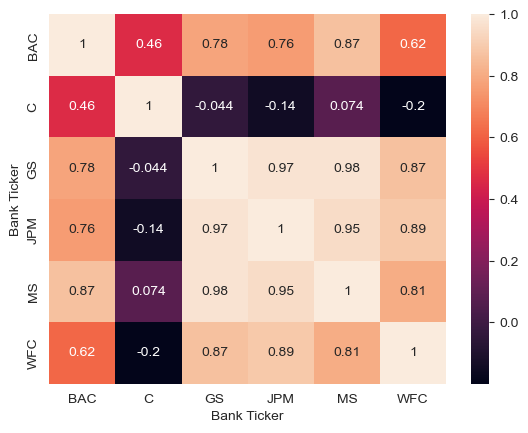

In [147]:
close_corr=sns.heatmap(bank_stocks.xs(key='Close',axis=1,level=1).corr(),annot= True)

In [157]:
#Plotly
close_corr.iplot(kind='heatmap',colorscale='rdylbu')

AttributeError: 'Axes' object has no attribute 'iplot'

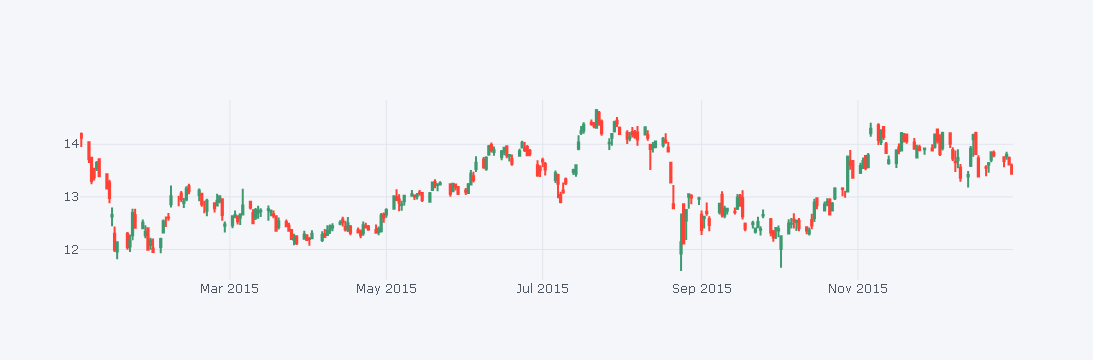

In [155]:
#Creating candle plot using plotly BAC
BAC[['Open','High','Low','Close']].loc['2015-01-01':'2016-01-01'].iplot(kind='candle')

C:\Users\cprad\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

C:\Users\cprad\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



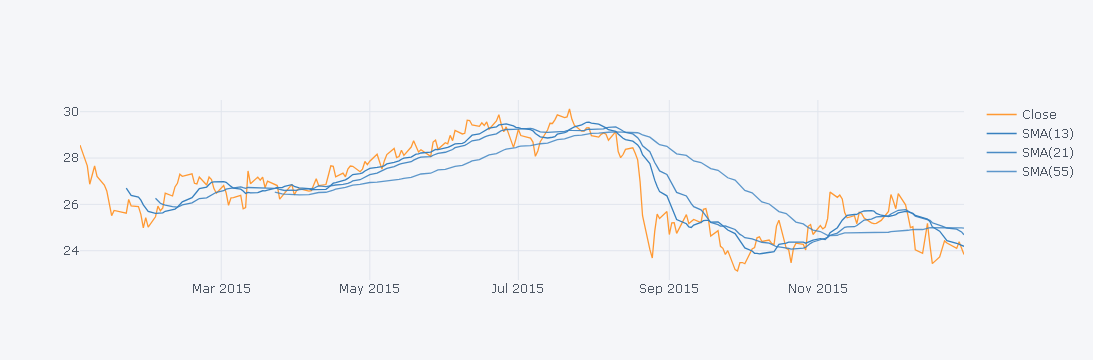

In [159]:
#Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.*
MS['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='sma',periods=[13,21,55],title='Simple Moving Averages')

C:\Users\cprad\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.

C:\Users\cprad\anaconda3\Lib\site-packages\cufflinks\plotlytools.py:117: FutureWarning:

DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.



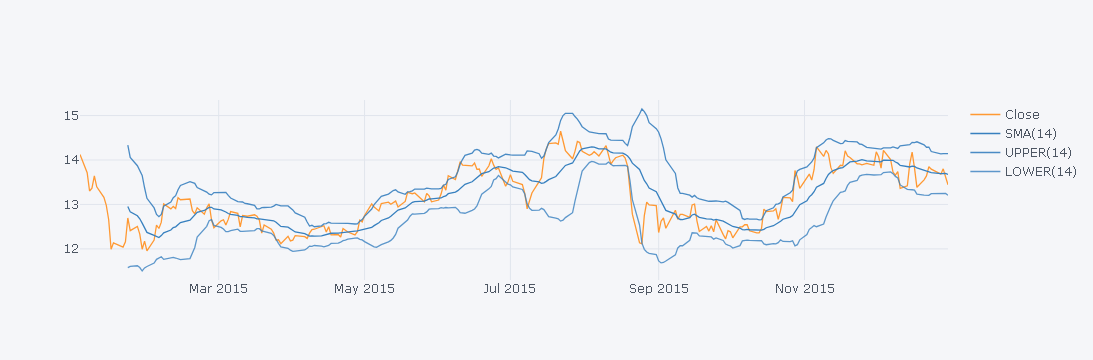

In [163]:
#Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.
BAC['Close'].loc['2015-01-01':'2016-01-01'].ta_plot(study='boll')
